In [1]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from PIL import Image

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

(np.float64(-0.5), np.float64(1919.5), np.float64(1491.5), np.float64(-0.5))

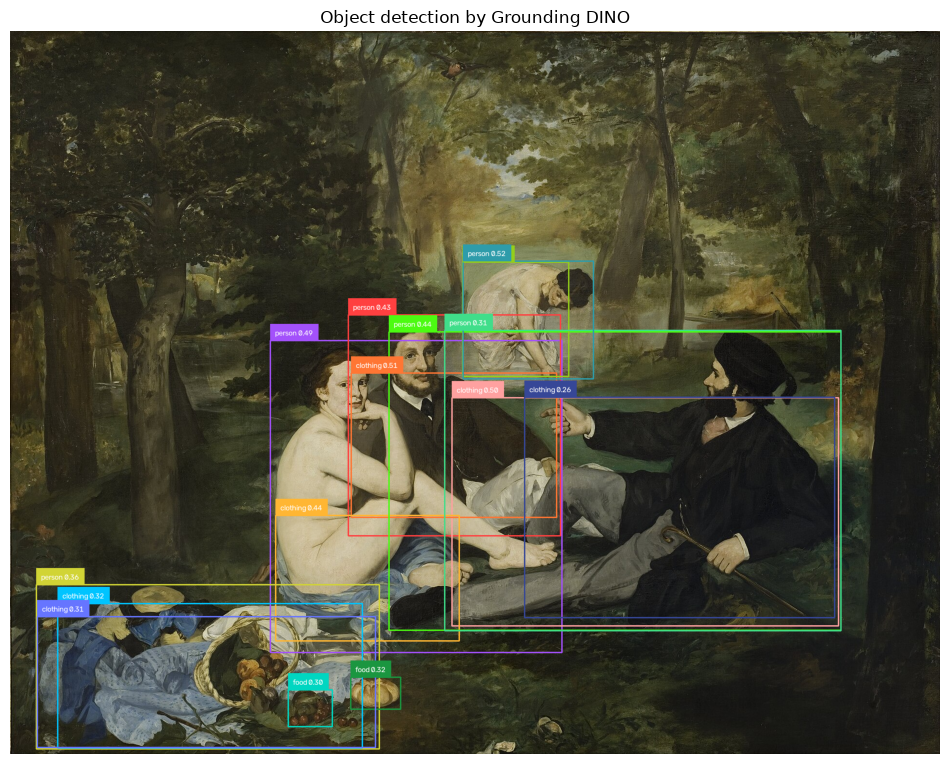

In [5]:
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

model_id = "IDEA-Research/grounding-dino-base"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(DEVICE)

IMAGE_PATH = "../data/raw_images/img_11.jpg"
image_pil = Image.open(IMAGE_PATH).convert('RGB')

image_cv2 = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)

#Manually defining tags to identify bounding boxes
text_labels = ["person", "animal", "basket", "food", "clothing"]

inputs = processor(images=image_pil, text=text_labels, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_grounded_object_detection(
    outputs,
    threshold=0.25,
    target_sizes=[image_pil.size[::-1]], 
    text_labels=[text_labels]
)[0]

boxes_array = results["boxes"].cpu().numpy()
conf_array = results["scores"].cpu().numpy()
labels_text = results["text_labels"]

if len(boxes_array) > 0:
    detections = sv.Detections(
        xyxy=boxes_array,
        confidence=conf_array,
        class_id=np.arange(len(labels_text)) 
    )
    
    custom_labels = [f"{label} {conf:.2f}" for label, conf in zip(labels_text, conf_array)]

    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()

    annotated_image = box_annotator.annotate(scene=image_cv2.copy(), detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections, labels=custom_labels)
else:
    print("No object detected with the current threshold")
    annotated_image = image_cv2.copy()

plt.figure(figsize=(12, 10))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.title("Object detection by Grounding DINO")
plt.axis('off')
